In [60]:
import sys
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import seaborn as sns
import json
import missingno as msno
import warnings
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import math
import shap
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/dataset_clinico.csv')
df

,subject_id,gender,anchor_age,charttime,hemoglobin,wbc,platelets,creatinine,glucose,weight,bmi,target,is_bpco,is_cancer_hist,is_smoker,avg_spo2,avg_resp_rate,avg_ldh,avg_albumin
0,10005428,M,52,2143-06-25 12:20:00,14.5,10.4,247.0,0.9,102.0,0.0,0.0,0,0,0,0.0,0.000000,0.000000,0.00,4.70
1,10005428,M,52,2143-06-25 19:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.000000,0.000000,0.00,4.70
2,10012268,M,22,2186-12-11 22:25:00,15.6,8.9,255.0,1.2,186.0,0.0,0.0,0,0,0,0.0,0.000000,0.000000,174.00,0.00
3,10013747,M,56,2121-06-19 15:25:00,15.5,7.5,291.0,1.2,126.0,175.2,27.2,0,0,0,0.0,0.000000,0.000000,0.00,4.45
4,10013747,M,56,2121-06-19 22:10:00,0.0,0.0,0.0,0.0,0.0,175.2,27.2,0,0,0,0.0,0.000000,0.000000,0.00,4.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183905,19998591,F,52,2185-07-29 05:49:00,9.8,5.5,524.0,1.0,73.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84
183906,19998591,F,52,2185-07-30 05:36:00,10.0,6.8,528.0,1.0,82.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84
183907,19998591,F,52,2185-07-31 06:31:00,9.7,5.7,468.0,0.8,82.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84
183908,19998591,F,52,2185-08-01 05:40:00,9.5,6.4,383.0,0.7,82.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [4]:
patients = df[['subject_id', 'target']].drop_duplicates()

<Axes: >

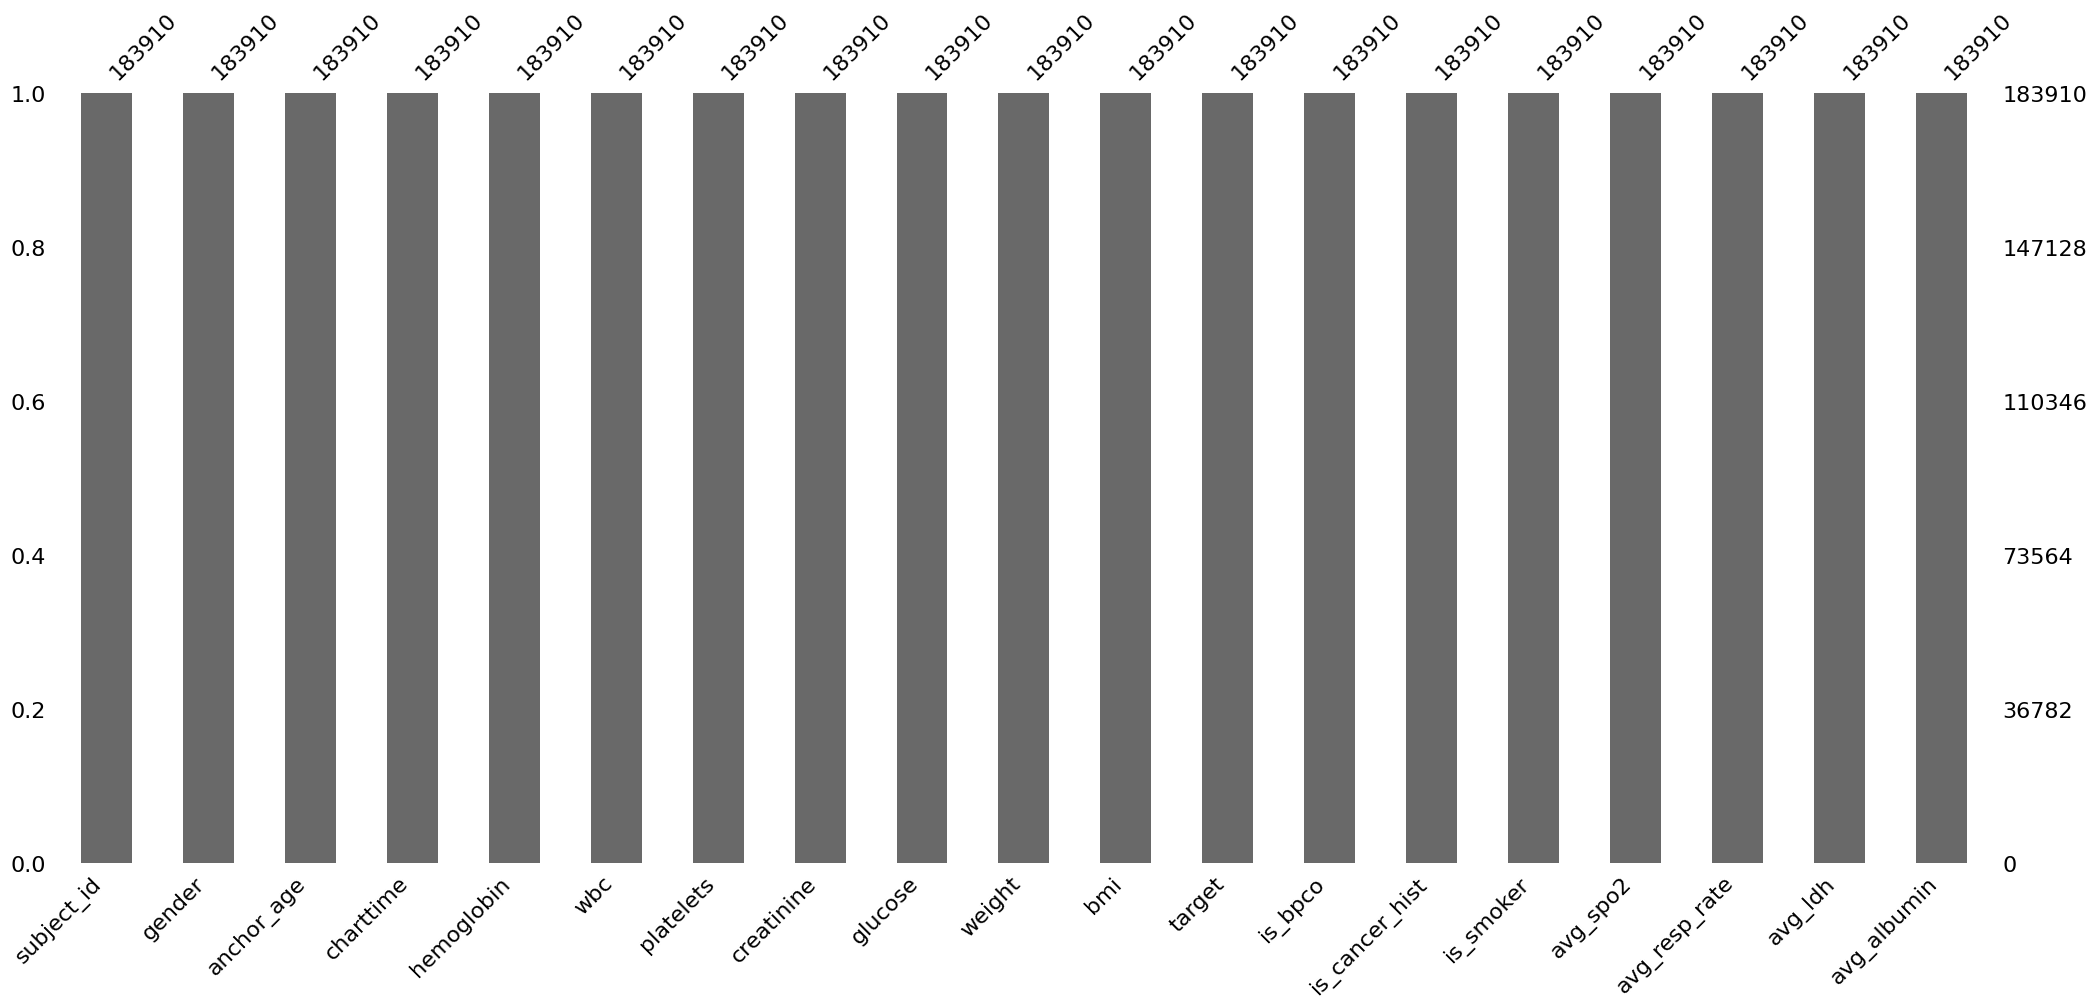

In [5]:
msno.bar(df)

In [6]:
def gestisci_missing_values(df_in):
    df_clean = df_in.copy()
    
    # 1. Feature Temporali (quelle originali che necessitano di Maschera)
    temporal_cols = ['hemoglobin', 'wbc', 'platelets', 'creatinine', 'glucose', 'weight', 'bmi']
    
    # 2. Nuove Feature Cliniche (estratte da chartevents, labevents e diagnosi)
    clinical_cols = ['is_bpco', 'is_cancer_hist', 'is_smoker', 'avg_spo2', 'avg_resp_rate', 'avg_ldh', 'avg_albumin']
    
    # Creazione Maschere solo per le variabili temporali (molto sparse)
    mask_cols = []
    for col in temporal_cols:
        mask_col_name = f"{col}_mask"
        df_clean[mask_col_name] = df_clean[col].notnull().astype(float)
        mask_cols.append(mask_col_name)
        
    # Uniamo tutte le colonne che devono essere propagate nel tempo per il paziente
    all_values_cols = temporal_cols + clinical_cols
    
    # Forward Fill raggruppato per paziente: 
    # Trasciniamo in avanti sia i laboratori che le nuove feature statiche
    df_clean[all_values_cols] = df_clean.groupby('subject_id')[all_values_cols].ffill()
    
    # Sostituzione NaN rimanenti con 0.0 (fondamentale per LDH e Albumina se mancano del tutto)
    df_clean[all_values_cols] = df_clean[all_values_cols].fillna(0.0)
    
    return df_clean, temporal_cols, clinical_cols, mask_cols

print("Elaborazione missingness e integrazione nuove feature in corso...")
df_clean, temporal_cols, clinical_cols, mask_cols = gestisci_missing_values(df)

# Ora l'input della LSTM passa da 14 a 21 colonne!
# (7 temporali + 7 maschere + 7 cliniche statiche)
all_cols = temporal_cols + mask_cols + clinical_cols 

print(f"Configurazione completata:")
print(f" - Feature con maschera: {len(temporal_cols)}")
print(f" - Feature cliniche extra: {len(clinical_cols)}")
print(f" - Totale colonne in input alla LSTM: {len(all_cols)}")

Elaborazione missingness e integrazione nuove feature in corso...
Configurazione completata:
 - Feature con maschera: 7
 - Feature cliniche extra: 7
 - Totale colonne in input alla LSTM: 21


<Axes: >

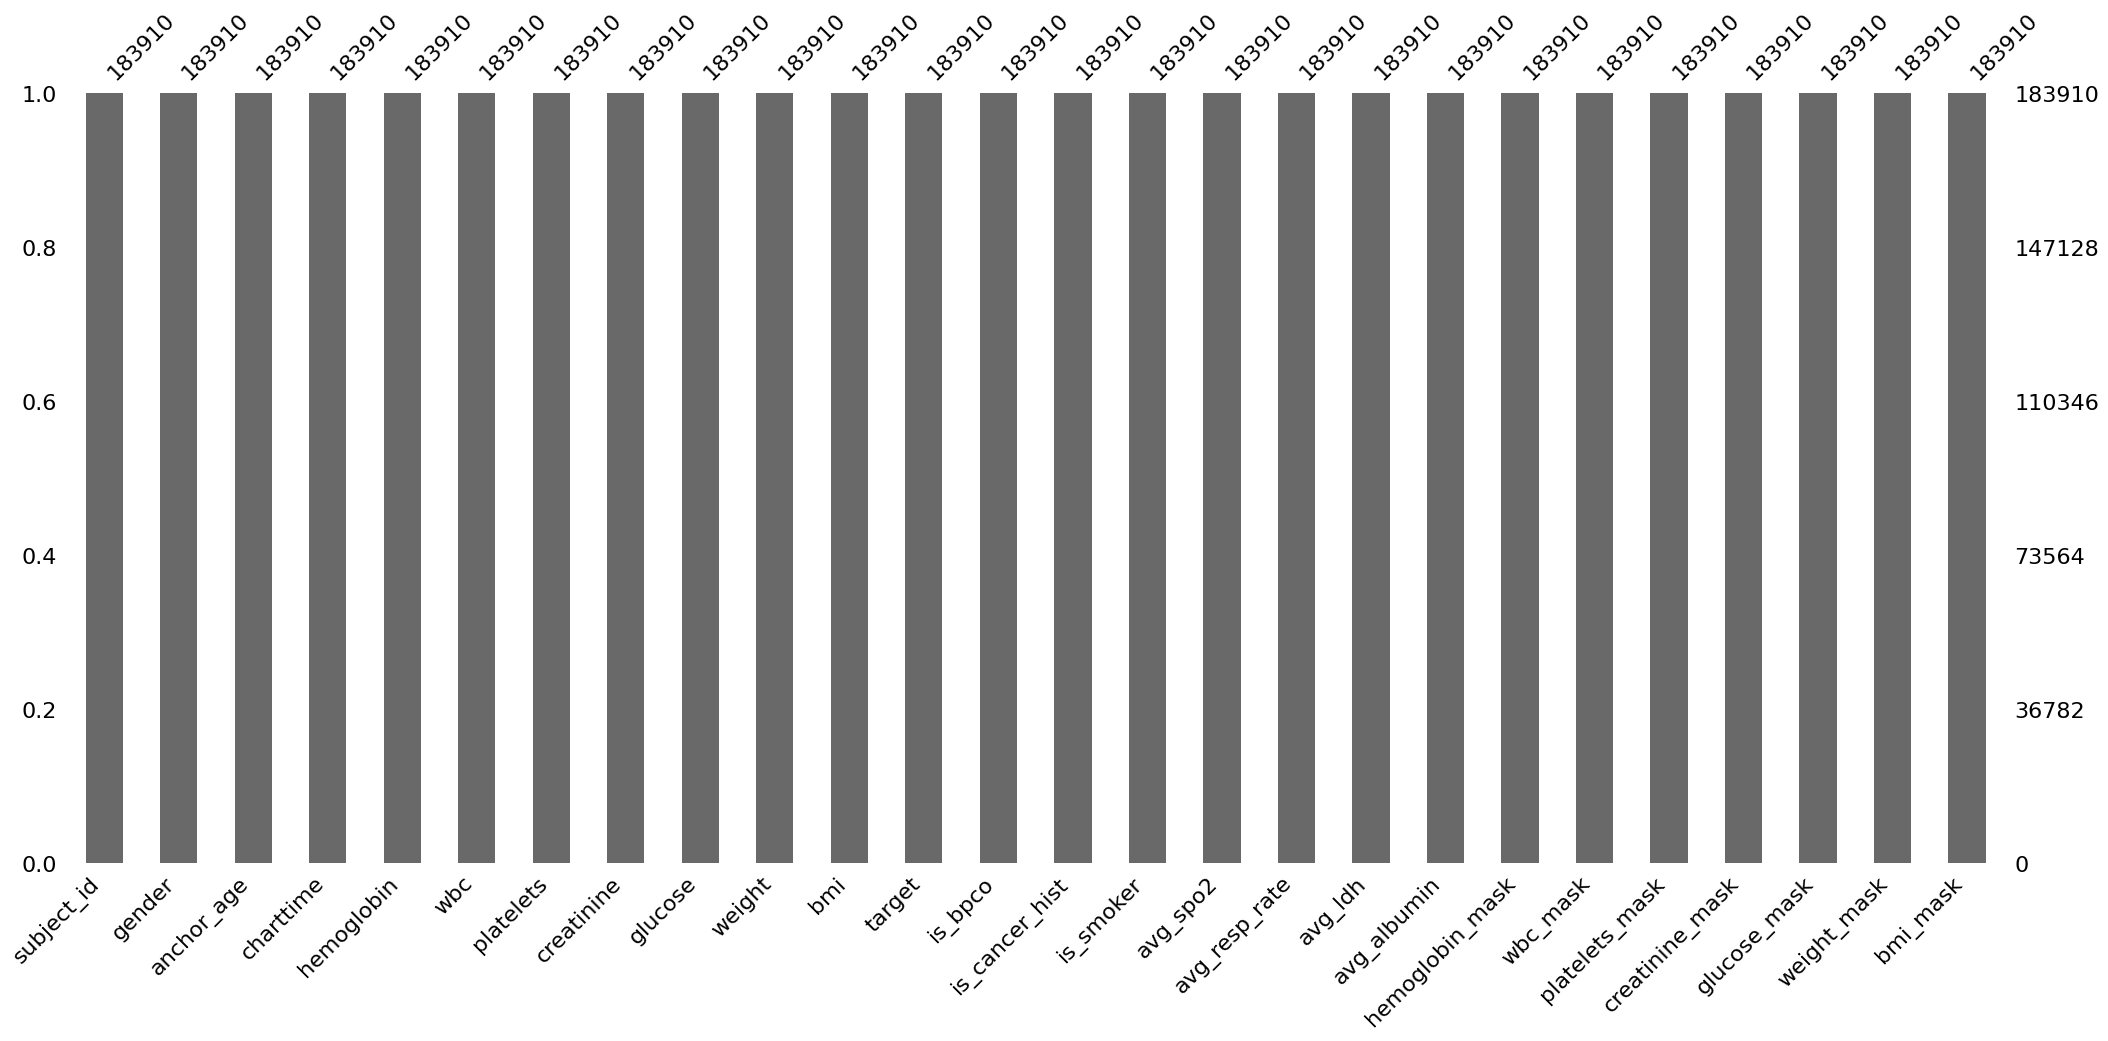

In [7]:
msno.bar(df_clean)

In [8]:
le = LabelEncoder()
df_corr = df_clean.drop(columns=['subject_id', 'charttime', 'target'])
df_corr = df_corr.drop(columns=mask_cols)
df_corr['gender'] = le.fit_transform(df_corr['gender'])
df_corr

,gender,anchor_age,hemoglobin,wbc,platelets,creatinine,glucose,weight,bmi,is_bpco,is_cancer_hist,is_smoker,avg_spo2,avg_resp_rate,avg_ldh,avg_albumin
0,1,52,14.5,10.4,247.0,0.9,102.0,0.0,0.0,0,0,0.0,0.000000,0.000000,0.00,4.70
1,1,52,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.000000,0.000000,0.00,4.70
2,1,22,15.6,8.9,255.0,1.2,186.0,0.0,0.0,0,0,0.0,0.000000,0.000000,174.00,0.00
3,1,56,15.5,7.5,291.0,1.2,126.0,175.2,27.2,0,0,0.0,0.000000,0.000000,0.00,4.45
4,1,56,0.0,0.0,0.0,0.0,0.0,175.2,27.2,0,0,0.0,0.000000,0.000000,0.00,4.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183905,0,52,9.8,5.5,524.0,1.0,73.0,0.0,0.0,0,1,0.0,116.584746,15.971602,307.25,1.84
183906,0,52,10.0,6.8,528.0,1.0,82.0,0.0,0.0,0,1,0.0,116.584746,15.971602,307.25,1.84
183907,0,52,9.7,5.7,468.0,0.8,82.0,0.0,0.0,0,1,0.0,116.584746,15.971602,307.25,1.84
183908,0,52,9.5,6.4,383.0,0.7,82.0,0.0,0.0,0,1,0.0,116.584746,15.971602,307.25,1.84


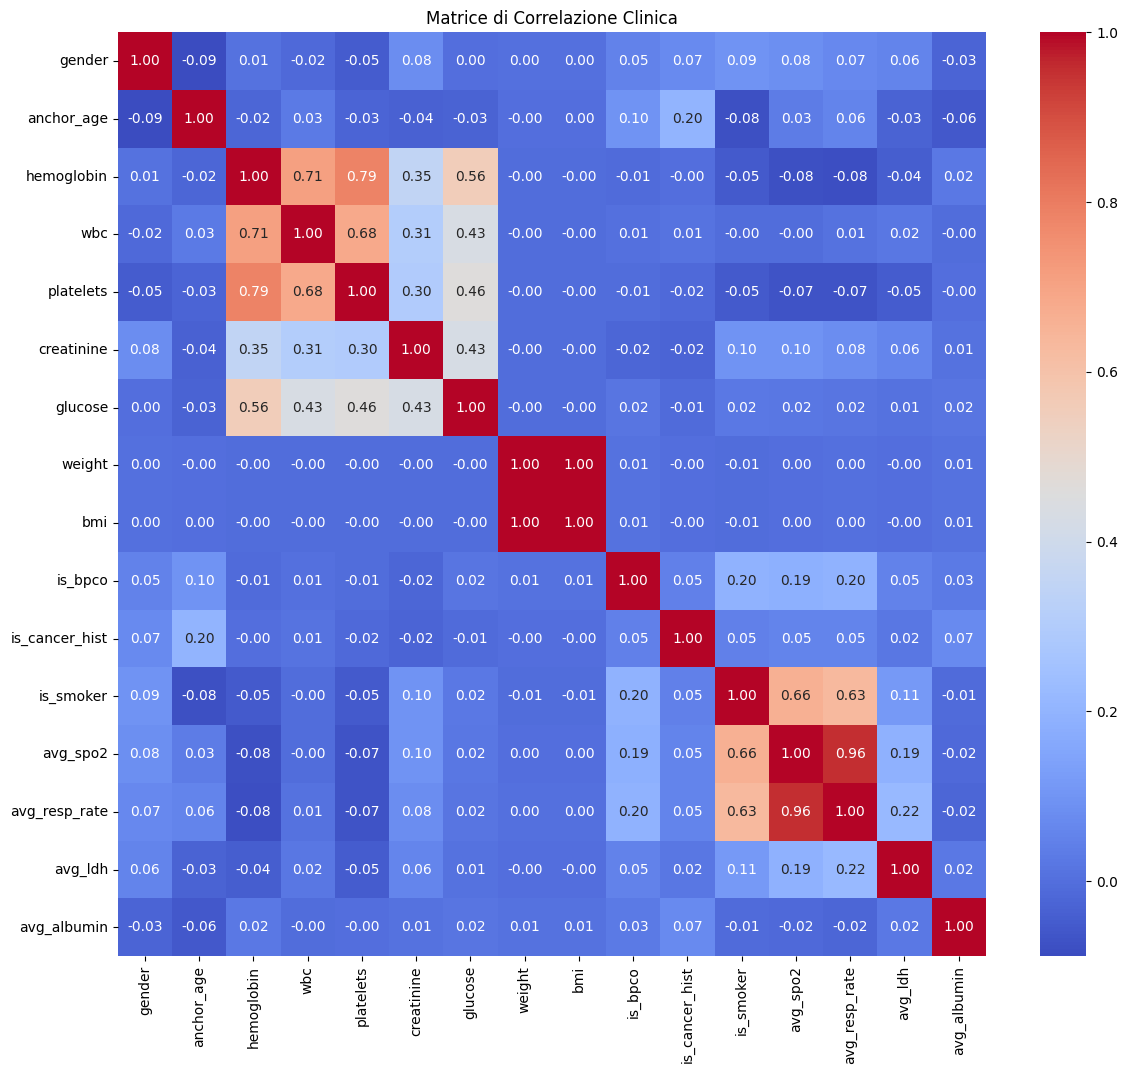

In [9]:
plt.figure(figsize=(14, 12))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice di Correlazione Clinica")
plt.show()

In [10]:
df_vif = df_corr.dropna()

# 2. Aggiungiamo l'intercetta (costante), necessaria per la formula matematica
X_vif = add_constant(df_vif)

# 3. Calcoliamo il VIF per ogni feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 4. Escludiamo la costante e ordiniamo dal più critico al più sano
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False).reset_index(drop=True)

# 5. Visualizziamo la tabella
display(vif_data)

,Feature,VIF
0,weight,270.275407
1,bmi,270.271329
2,avg_spo2,12.547373
3,avg_resp_rate,11.961291
4,hemoglobin,3.454344
5,platelets,2.891586
6,wbc,2.243069
7,is_smoker,1.847033
8,glucose,1.603366
9,creatinine,1.298581


In [11]:
# 1. Rimuoviamo un elemento per ogni coppia altamente correlata
feature_da_droppare = ['weight', 'avg_resp_rate']
df_corr_pulito = df_corr.drop(columns=feature_da_droppare)

# 2. Ricalcoliamo il VIF per vedere la magia
df_vif_pulito = df_corr_pulito.dropna()
X_vif_pulito = add_constant(df_vif_pulito)

vif_data_pulito = pd.DataFrame()
vif_data_pulito["Feature"] = X_vif_pulito.columns
vif_data_pulito["VIF"] = [variance_inflation_factor(X_vif_pulito.values, i) for i in range(len(X_vif_pulito.columns))]
vif_data_pulito = vif_data_pulito[vif_data_pulito['Feature'] != 'const'].sort_values(by="VIF", ascending=False).reset_index(drop=True)

display(vif_data_pulito)

,Feature,VIF
0,hemoglobin,3.449920
1,platelets,2.891582
2,wbc,2.235239
3,avg_spo2,1.878255
4,is_smoker,1.846963
5,glucose,1.603135
6,creatinine,1.295873
7,anchor_age,1.099846
8,is_bpco,1.066946
9,is_cancer_hist,1.062510


In [12]:
def gestisci_missing_values_ottimizzato(df_in):
    df_clean = df_in.copy()
    
    # 1. Feature Temporali (RIMOSSO 'weight' per alto VIF, tenuto 'bmi')
    temporal_cols = ['hemoglobin', 'wbc', 'platelets', 'creatinine', 'glucose', 'bmi']
    
    # 2. Feature Cliniche/Statiche (RIMOSSO 'avg_resp_rate' per alto VIF)
    clinical_cols = ['is_bpco', 'is_cancer_hist', 'is_smoker', 'avg_spo2', 'avg_ldh', 'avg_albumin']
    
    # Creazione Maschere SOLO per le variabili temporali
    mask_cols = []
    for col in temporal_cols:
        mask_col_name = f"{col}_mask"
        df_clean[mask_col_name] = df_clean[col].notnull().astype(float)
        mask_cols.append(mask_col_name)
        
    # Uniamo le colonne per il riempimento
    all_values_cols = temporal_cols + clinical_cols
    
    # Forward Fill raggruppato per paziente
    df_clean[all_values_cols] = df_clean.groupby('subject_id')[all_values_cols].ffill()
    
    # Sostituzione NaN rimanenti con 0.0 (o un valore di default clinico)
    df_clean[all_values_cols] = df_clean[all_values_cols].fillna(0.0)
    
    return df_clean, temporal_cols, clinical_cols, mask_cols

print("Elaborazione missingness e integrazione in corso...")
df_clean, temporal_cols, clinical_cols, mask_cols = gestisci_missing_values_ottimizzato(df)

# Configurazione finale per il Modello Ibrido:
input_dim_lstm = len(temporal_cols) + len(mask_cols)
input_dim_mlp = len(clinical_cols) # Più eventuali altre feature statiche come 'anchor_age' e 'gender'

print(f"Configurazione completata per Rete Ibrida:")
print(f" - Dimensioni Input LSTM (Temporali + Maschere): {input_dim_lstm}")
print(f" - Dimensioni Input parziale MLP (Statiche): {input_dim_mlp}")

Elaborazione missingness e integrazione in corso...
Configurazione completata per Rete Ibrida:
 - Dimensioni Input LSTM (Temporali + Maschere): 12
 - Dimensioni Input parziale MLP (Statiche): 6


In [13]:
df_clean = df_clean.drop(columns=feature_da_droppare)
df_clean, temporal_cols, clinical_cols, mask_cols = gestisci_missing_values_ottimizzato(df)
df_clean

,subject_id,gender,anchor_age,charttime,hemoglobin,wbc,platelets,creatinine,glucose,weight,...,avg_spo2,avg_resp_rate,avg_ldh,avg_albumin,hemoglobin_mask,wbc_mask,platelets_mask,creatinine_mask,glucose_mask,bmi_mask
0,10005428,M,52,2143-06-25 12:20:00,14.5,10.4,247.0,0.9,102.0,0.0,...,0.000000,0.000000,0.00,4.70,1.0,1.0,1.0,1.0,1.0,1.0
1,10005428,M,52,2143-06-25 19:30:00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.00,4.70,1.0,1.0,1.0,1.0,1.0,1.0
2,10012268,M,22,2186-12-11 22:25:00,15.6,8.9,255.0,1.2,186.0,0.0,...,0.000000,0.000000,174.00,0.00,1.0,1.0,1.0,1.0,1.0,1.0
3,10013747,M,56,2121-06-19 15:25:00,15.5,7.5,291.0,1.2,126.0,175.2,...,0.000000,0.000000,0.00,4.45,1.0,1.0,1.0,1.0,1.0,1.0
4,10013747,M,56,2121-06-19 22:10:00,0.0,0.0,0.0,0.0,0.0,175.2,...,0.000000,0.000000,0.00,4.45,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183905,19998591,F,52,2185-07-29 05:49:00,9.8,5.5,524.0,1.0,73.0,0.0,...,116.584746,15.971602,307.25,1.84,1.0,1.0,1.0,1.0,1.0,1.0
183906,19998591,F,52,2185-07-30 05:36:00,10.0,6.8,528.0,1.0,82.0,0.0,...,116.584746,15.971602,307.25,1.84,1.0,1.0,1.0,1.0,1.0,1.0
183907,19998591,F,52,2185-07-31 06:31:00,9.7,5.7,468.0,0.8,82.0,0.0,...,116.584746,15.971602,307.25,1.84,1.0,1.0,1.0,1.0,1.0,1.0
183908,19998591,F,52,2185-08-01 05:40:00,9.5,6.4,383.0,0.7,82.0,0.0,...,116.584746,15.971602,307.25,1.84,1.0,1.0,1.0,1.0,1.0,1.0


In [14]:
def plot_clinical_boxplots(df, feature_cols, target_col='target'):
    
    n_features = len(feature_cols)
    cols = 4 # Layout a 4 colonne
    rows = math.ceil(n_features / cols)
    
    # Imposta dinamicamente l'altezza in base al numero di righe
    plt.figure(figsize=(16, 4 * rows))
    
    for i, col in enumerate(feature_cols, 1):
        plt.subplot(rows, cols, i)
        
        # Generazione del boxplot (0 = Sano, 1 = Malato)
        sns.boxplot(data=df, x=target_col, y=col, palette='Set2')
        
        # Estetica del grafico
        plt.title(f"Distribuzione di {col}", fontsize=12, fontweight='bold')
        plt.xlabel("Target (0=Sano, 1=Malato)", fontsize=10)
        plt.ylabel("Valore", fontsize=10)
        
    # Ottimizza gli spazi tra i grafici
    plt.tight_layout()
    plt.show()

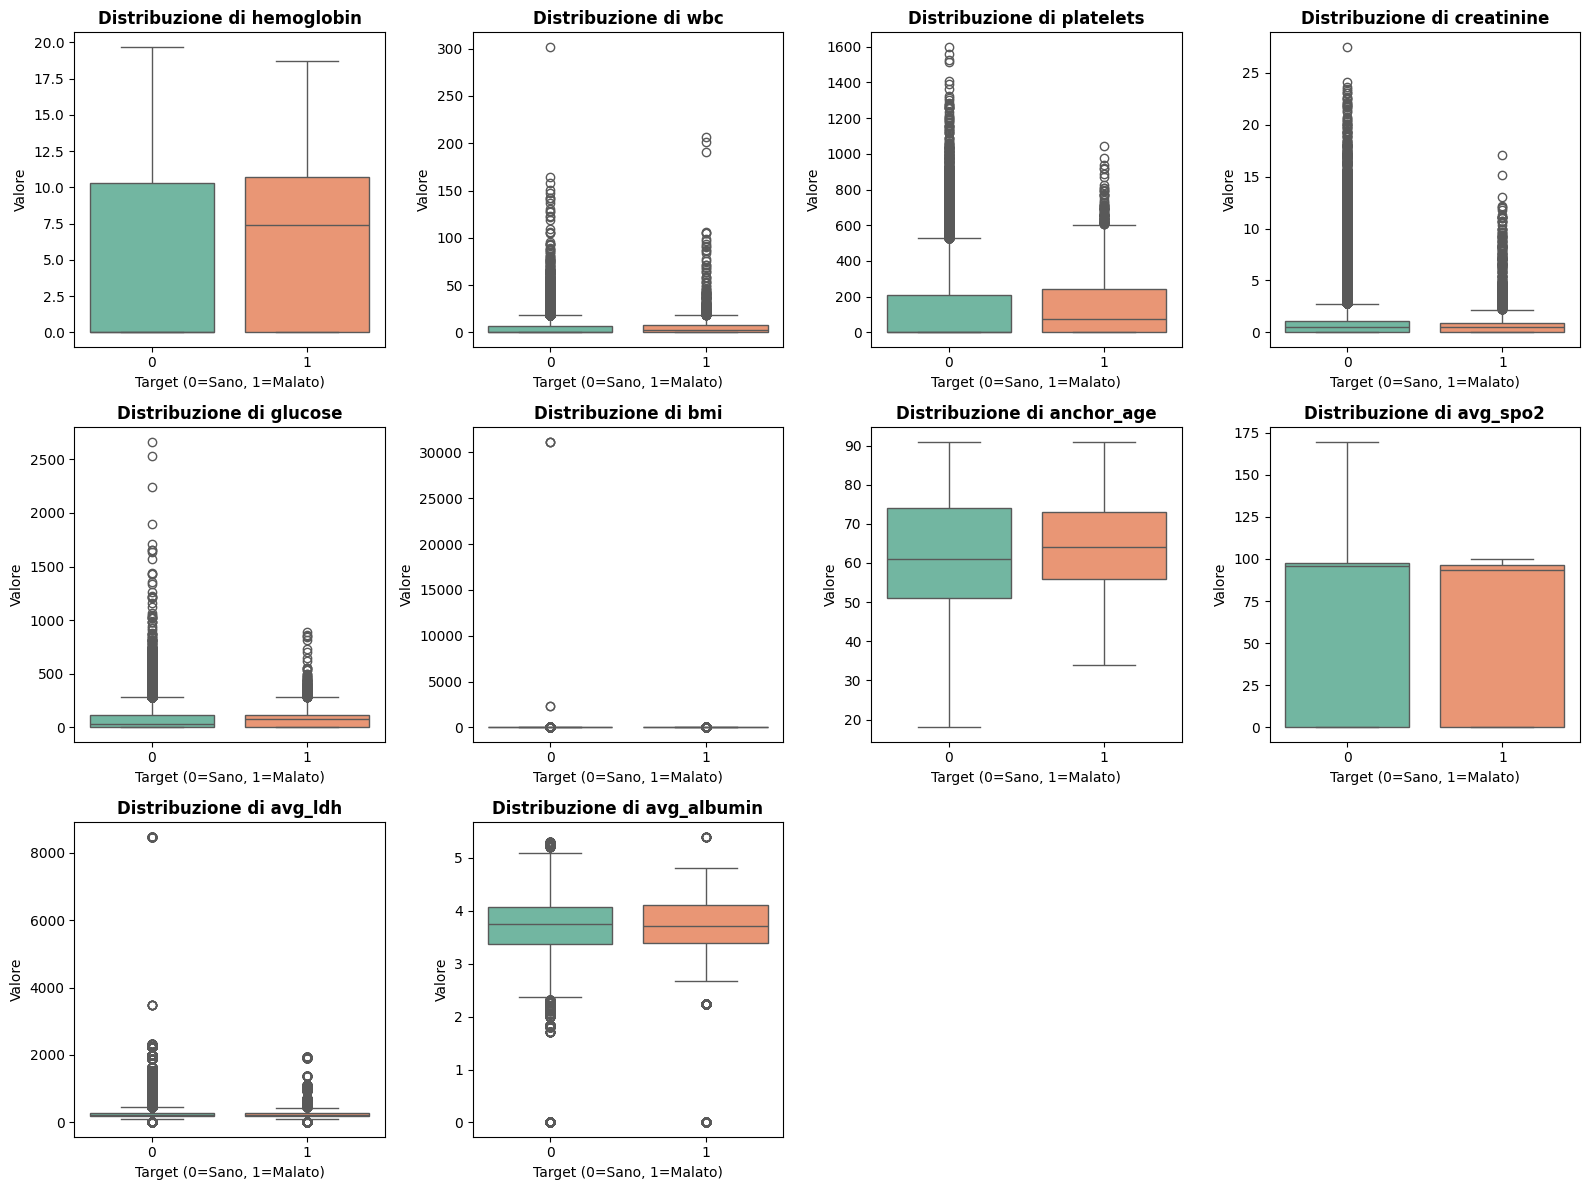

In [15]:
colonne_continue = ['hemoglobin', 'wbc', 'platelets', 'creatinine', 'glucose', 'bmi', 
                    'anchor_age', 'avg_spo2', 'avg_ldh', 'avg_albumin']

plot_clinical_boxplots(df_clean, colonne_continue, target_col='target')

In [16]:
df_clean['bmi'] = df_clean['bmi'].clip(lower=10, upper=80)
df_clean['avg_spo2'] = df_clean['avg_spo2'].clip(lower=40, upper=100) 
df_clean['glucose'] = df_clean['glucose'].clip(lower=20, upper=1000)

# 2. Limiti Statistici (Percentili) per le altre code lunghe
# Tagliamo tutto ciò che è sopra il 99° percentile per evitare che distrugga i pesi
colonne_da_clippare = ['hemoglobin', 'wbc', 'platelets', 'creatinine', 'avg_ldh', 'avg_albumin']

for col in colonne_da_clippare:
    # Calcoliamo il 99° percentile escludendo i nostri zeri artificiali
    valori_reali = df_clean[df_clean[col] > 0][col]
    
    if not valori_reali.empty:
        limite_superiore = valori_reali.quantile(0.99)
        # Tagliamo i picchi estremi
        df_clean[col] = df_clean[col].clip(upper=limite_superiore)

print("Outlier tagliati con successo!")

Outlier tagliati con successo!


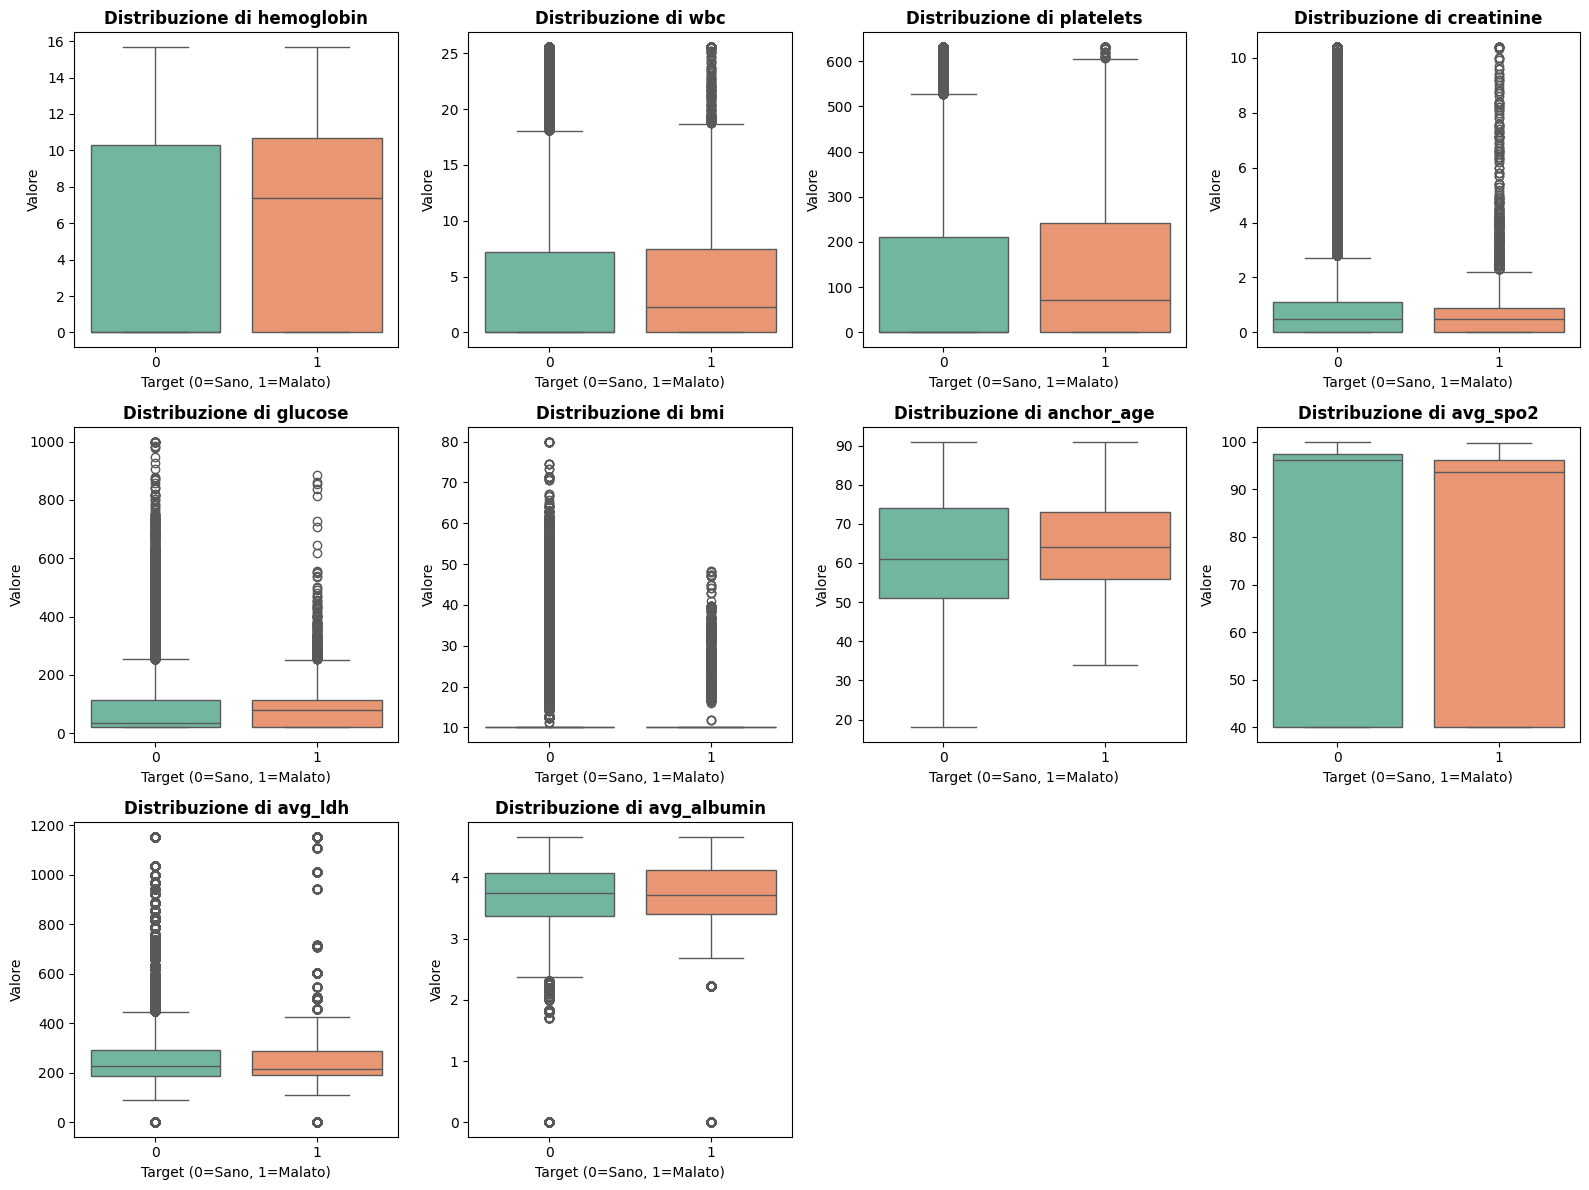

In [17]:
plot_clinical_boxplots(df_clean, colonne_continue, target_col='target')

In [ ]:
scaler = StandardScaler()

df_clean[colonne_continue] = scaler.fit_transform(df_clean[colonne_continue])
print("Scaling completato! I dati continui ora hanno media 0 e varianza 1.")

Scaling completato! I dati continui ora hanno media 0 e varianza 1.


Addestramento Random Forest per Feature Selection...


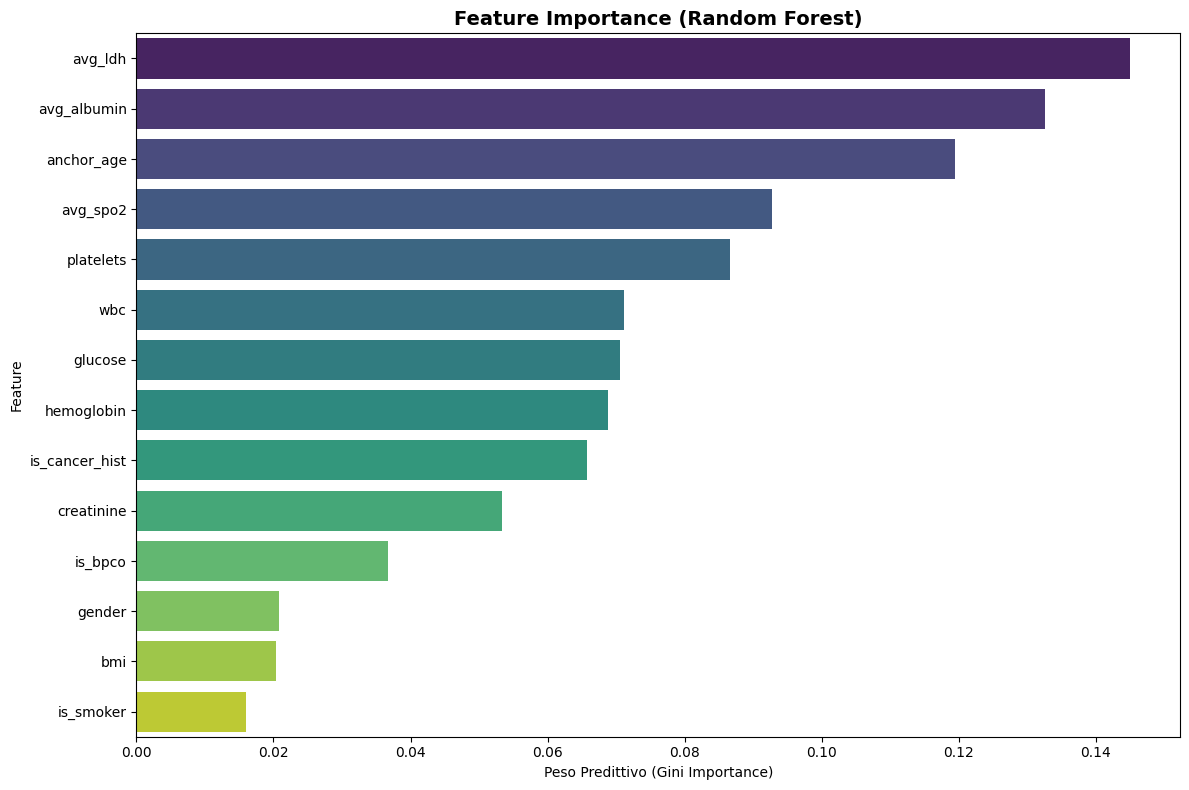

,Feature,Importanza
8,avg_ldh,0.145042
9,avg_albumin,0.132600
6,anchor_age,0.119392
7,avg_spo2,0.092741
2,platelets,0.086607
1,wbc,0.071219
4,glucose,0.070598
0,hemoglobin,0.068787
11,is_cancer_hist,0.065694
3,creatinine,0.053381


In [22]:
feature_da_valutare = [
    'hemoglobin', 'wbc', 'platelets', 'creatinine', 'glucose', 'bmi', 
    'anchor_age', 'avg_spo2', 'avg_ldh', 'avg_albumin',
    'is_bpco', 'is_cancer_hist', 'is_smoker', 'gender'
]

df_flat = df_clean.groupby('subject_id').last().reset_index()
df_flat['gender'] = le.fit_transform(df_flat['gender'])

# 3. Prepariamo X (le feature) e y (il target)
X_fs = df_flat[feature_da_valutare]
y_fs = df_flat['target']

# 4. Addestriamo un Random Forest rapido
print("Addestramento Random Forest per Feature Selection...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_fs, y_fs)

# 5. Estraiamo l'importanza e creiamo un DataFrame per il grafico
importanza = pd.DataFrame({
    'Feature': feature_da_valutare,
    'Importanza': rf.feature_importances_
}).sort_values(by='Importanza', ascending=False)

# 6. Disegniamo il grafico a barre per la Tesi
plt.figure(figsize=(12, 8))
sns.barplot(data=importanza, x='Importanza', y='Feature', palette='viridis')
plt.title("Feature Importance (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Peso Predittivo (Gini Importance)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Stampiamo anche i numeri esatti
display(importanza)

In [23]:
df_clean = df_clean.drop(columns=['gender', 'is_smoker'])
df_clean

,subject_id,anchor_age,charttime,hemoglobin,wbc,platelets,creatinine,glucose,weight,bmi,...,avg_spo2,avg_resp_rate,avg_ldh,avg_albumin,hemoglobin_mask,wbc_mask,platelets_mask,creatinine_mask,glucose_mask,bmi_mask
0,10005428,-0.615371,2143-06-25 12:20:00,1.731604,1.273616,0.979100,-0.004790,0.311305,0.0,-0.222946,...,-1.535487,0.000000,-1.546867,1.347418,1.0,1.0,1.0,1.0,1.0,1.0
1,10005428,-0.615371,2143-06-25 19:30:00,-0.912231,-0.768627,-0.786461,-0.569613,-0.756485,0.0,-0.222946,...,-1.535487,0.000000,-1.546867,1.347418,1.0,1.0,1.0,1.0,1.0,1.0
2,10012268,-2.492007,2186-12-11 22:25:00,1.932171,0.979062,1.036284,0.183484,1.405139,0.0,-0.222946,...,-1.535487,0.000000,-0.486238,-4.615133,1.0,1.0,1.0,1.0,1.0,1.0
3,10013747,-0.365152,2121-06-19 15:25:00,1.913937,0.704145,1.293613,0.183484,0.623829,175.2,3.028856,...,-1.535487,0.000000,-1.546867,1.070585,1.0,1.0,1.0,1.0,1.0,1.0
4,10013747,-0.365152,2121-06-19 22:10:00,-0.912231,-0.768627,-0.786461,-0.569613,-0.756485,175.2,3.028856,...,-1.535487,0.000000,-1.546867,1.070585,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183905,19998591,-0.615371,2185-07-29 05:49:00,0.874637,0.311406,2.959102,0.057968,-0.066328,0.0,-0.222946,...,0.778079,15.971602,0.325996,-2.264184,1.0,1.0,1.0,1.0,1.0,1.0
183906,19998591,-0.615371,2185-07-30 05:36:00,0.911103,0.566686,2.987694,0.057968,0.050869,0.0,-0.222946,...,0.778079,15.971602,0.325996,-2.264184,1.0,1.0,1.0,1.0,1.0,1.0
183907,19998591,-0.615371,2185-07-31 06:31:00,0.856403,0.350680,2.558813,-0.067548,0.050869,0.0,-0.222946,...,0.778079,15.971602,0.325996,-2.264184,1.0,1.0,1.0,1.0,1.0,1.0
183908,19998591,-0.615371,2185-08-01 05:40:00,0.819937,0.488138,1.951231,-0.130306,0.050869,0.0,-0.222946,...,0.778079,15.971602,0.325996,-2.264184,1.0,1.0,1.0,1.0,1.0,1.0


In [24]:
clinical_cols = ['is_bpco', 'is_cancer_hist', 'avg_spo2', 'avg_ldh', 'avg_albumin']

# 2. Aggiorna le colonne in input allo specialista MLP (via 'gender')
# Ricorda che 'anchor_age' rimane perché era sul podio della Feature Selection!
colonne_mlp = clinical_cols + ['anchor_age']

In [25]:
class MimicDataset(Dataset):
    def __init__(self, df, seq_cols, static_cols):
        self.seq_cols = seq_cols
        self.static_cols = static_cols
        self.grouped = df.sort_values(['subject_id', 'charttime']).groupby('subject_id')
        self.patient_ids = list(self.grouped.groups.keys())

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, ind):
        patient_id = self.patient_ids[ind]
        patient_data = self.grouped.get_group(patient_id)
        
        # 1. Feature per LSTM (Sequenze temporali)
        x_seq = patient_data[self.seq_cols].values
        
        # 2. Feature per MLP (Dati statici/medi del paziente)
        # Prendiamo solo la prima riga perché fumo, BPCO, etc. sono uguali per tutta la sequenza
        x_static = patient_data[self.static_cols].iloc[0].values
        
        y = patient_data['target'].iloc[0]
        
        return (torch.tensor(x_seq, dtype=torch.float32), 
                torch.tensor(x_static, dtype=torch.float32), 
                torch.tensor(y, dtype=torch.float32))

    

In [26]:
def mimic_collate(batch):
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    sequences, statics, targets = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    
    # Padding solo per le sequenze della LSTM
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    
    return padded_seqs, torch.stack(statics), torch.tensor(targets), lengths

In [ ]:
class Mimic_LSTM(nn.Module):
    def __init__(self, seq_input_size=14, static_input_size=7, hidden_size=64):
        super(Mimic_LSTM, self).__init__()
        self.lstm = nn.LSTM(seq_input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + static_input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1) 
        )

    def forward(self, x_seq, lengths, x_static):
        packed_x = torch.nn.utils.rnn.pack_padded_sequence(x_seq, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed_x)
        lstm_out = hn[-1] 
        combined = torch.cat((lstm_out, x_static), dim=1)
        return self.classifier(combined).squeeze(1)


In [30]:
temporal_cols = ['hemoglobin', 'wbc', 'platelets', 'creatinine', 'glucose', 'bmi']
mask_cols = [f"{col}_mask" for col in temporal_cols]
clinical_cols = ['is_bpco', 'is_cancer_hist', 'avg_spo2', 'avg_ldh', 'avg_albumin']

colonne_lstm = temporal_cols + mask_cols
colonne_mlp = clinical_cols + ['anchor_age'] # gender e is_smoker rimossi

# Dimensioni dinamiche per la rete
DIM_SEQ = len(colonne_lstm)
DIM_STATIC = len(colonne_mlp)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [ ]:
K = 5
epochs = 25
patience = 3 

cv_patients, test_patients = train_test_split(
    patients, test_size=0.15, random_state=42, stratify=patients['target']
)

history = {'train_loss': [], 'val_loss': []}
all_fold_preds = []
all_fold_targets = []

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

print(f"\n--- Inizio {K}-Fold Cross Validation con Early Stopping ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(cv_patients['subject_id'], cv_patients['target'])):
    print(f"\n--- Preparazione FOLD {fold+1}/{K} ---")
    
    # Reset per ogni FOLD
    fold_train_losses = []
    fold_val_losses = []
    best_val_loss_fold = float('inf')
    early_stop_counter = 0
    
    # 1-4. Setup Dati
    train_ids = cv_patients.iloc[train_idx]['subject_id'].values
    val_ids = cv_patients.iloc[val_idx]['subject_id'].values
    train_df = df_clean[df_clean['subject_id'].isin(train_ids)].copy()
    val_df = df_clean[df_clean['subject_id'].isin(val_ids)].copy()
    
    train_dataset = MimicDataset(train_df, seq_cols=colonne_lstm, static_cols=colonne_mlp)
    val_dataset = MimicDataset(val_df, seq_cols=colonne_lstm, static_cols=colonne_mlp)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=mimic_collate)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=mimic_collate)
    
    # 5. Modello e Optimizer
    model = Mimic_LSTM(seq_input_size=DIM_SEQ, static_input_size=DIM_STATIC, hidden_size=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Peso per sbilanciamento
    num_sani = (train_df.groupby('subject_id')['target'].first() == 0).sum()
    num_malati = (train_df.groupby('subject_id')['target'].first() == 1).sum()
    peso_positivo = torch.tensor([num_sani / num_malati]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=peso_positivo)

    # CICLO EPOCHE
    for epoch in range(epochs):
        # --- PHASE 1: TRAINING ---
        model.train()
        train_loss = 0
        for seqs, statics, targets, lengths in train_loader:
            seqs, statics, targets = seqs.to(device), statics.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(seqs, lengths, statics)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)

        # --- PHASE 2: VALIDATION ---
        model.eval()
        val_loss = 0
        y_true_epoch, y_pred_epoch = [], []
        
        with torch.no_grad():
            for seqs, statics, targets, lengths in val_loader:
                seqs, statics, targets = seqs.to(device), statics.to(device), targets.to(device)
                outputs = model(seqs, lengths, statics)
                v_loss = criterion(outputs, targets)
                val_loss += v_loss.item()
                
                probs = torch.sigmoid(outputs).cpu().numpy()
                y_pred_epoch.extend(probs)
                y_true_epoch.extend(targets.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        
        # Salvataggio andamento
        fold_train_losses.append(avg_train_loss)
        fold_val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # LOGICA EARLY STOPPING
        if avg_val_loss < best_val_loss_fold:
            best_val_loss_fold = avg_val_loss
            early_stop_counter = 0
            # Salviamo lo stato migliore di questo fold
            torch.save(model.state_dict(), f'best_model_fold_{fold+1}.pth')
            # Teniamo traccia delle predizioni migliori per la matrice di confusione
            best_preds_fold = y_pred_epoch
            best_targets_fold = y_true_epoch
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early Stopping al Fold {fold+1} all'epoca {epoch+1} ---")
                break

    # Salvataggio risultati del Fold nella storia globale
    history['train_loss'].append(fold_train_losses)
    history['val_loss'].append(fold_val_losses)
    all_fold_preds.extend(best_preds_fold)
    all_fold_targets.extend(best_targets_fold)


--- Inizio 5-Fold Cross Validation con Early Stopping ---

--- Preparazione FOLD 1/5 ---
Epoch 01 | Train Loss: 1.2749 | Val Loss: 1.2223
Epoch 02 | Train Loss: 1.1610 | Val Loss: 1.1601
Epoch 03 | Train Loss: 1.0972 | Val Loss: 1.1024
Epoch 04 | Train Loss: 0.9991 | Val Loss: 1.0588
Epoch 05 | Train Loss: 0.9604 | Val Loss: 1.0258
Epoch 06 | Train Loss: 0.9395 | Val Loss: 1.0120
Epoch 07 | Train Loss: 0.8893 | Val Loss: 0.9840
Epoch 08 | Train Loss: 0.8773 | Val Loss: 0.9890
Epoch 09 | Train Loss: 0.8299 | Val Loss: 0.9935
Epoch 10 | Train Loss: 0.8355 | Val Loss: 0.9902
Early Stopping al Fold 1 all'epoca 10 ---

--- Preparazione FOLD 2/5 ---
Epoch 01 | Train Loss: 1.2896 | Val Loss: 1.2409
Epoch 02 | Train Loss: 1.1550 | Val Loss: 1.1364
Epoch 03 | Train Loss: 1.0602 | Val Loss: 1.0875
Epoch 04 | Train Loss: 0.9767 | Val Loss: 1.1131
Epoch 05 | Train Loss: 0.9455 | Val Loss: 1.0778
Epoch 06 | Train Loss: 0.9287 | Val Loss: 1.0033
Epoch 07 | Train Loss: 0.9262 | Val Loss: 0.9986
Epoc

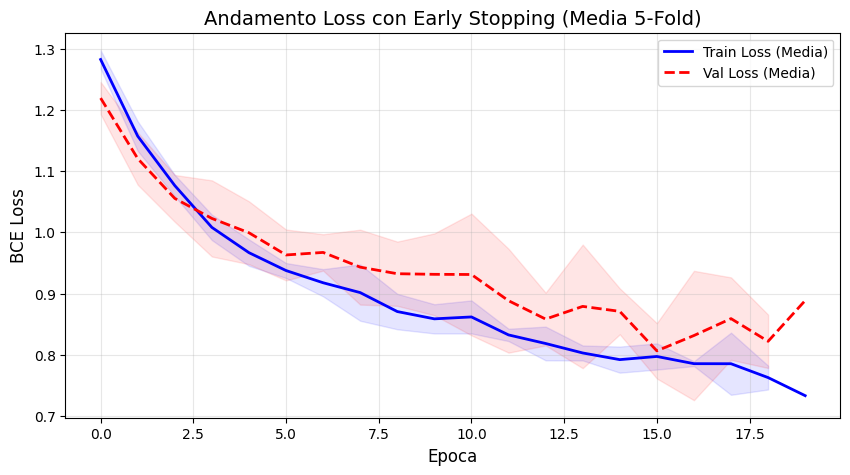

In [49]:
plt.figure(figsize=(10, 5))

# Trasformiamo le liste di lunghezze diverse in DataFrame
# Pandas riempirà i "buchi" con NaN (Not a Number)
df_train = pd.DataFrame(history['train_loss']).T
df_val = pd.DataFrame(history['val_loss']).T

# Calcoliamo la media riga per riga (epoca per epoca) ignorando i NaN
mean_train_loss = df_train.mean(axis=1)
mean_val_loss = df_val.mean(axis=1)

# Calcoliamo anche la deviazione standard per l'area d'ombra (molto professionale!)
std_train = df_train.std(axis=1)
std_val = df_val.std(axis=1)

# Plot delle linee medie
plt.plot(mean_train_loss, label='Train Loss (Media)', color='blue', lw=2)
plt.plot(mean_val_loss, label='Val Loss (Media)', color='red', linestyle='--', lw=2)

# Aggiungiamo l'area di varianza (opzionale, ma fa un figurone)
plt.fill_between(range(len(mean_train_loss)), mean_train_loss - std_train, mean_train_loss + std_train, color='blue', alpha=0.1)
plt.fill_between(range(len(mean_val_loss)), mean_val_loss - std_val, mean_val_loss + std_val, color='red', alpha=0.1)

plt.title('Andamento Loss con Early Stopping (Media 5-Fold)', fontsize=14)
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('BCE Loss', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<Figure size 800x600 with 0 Axes>

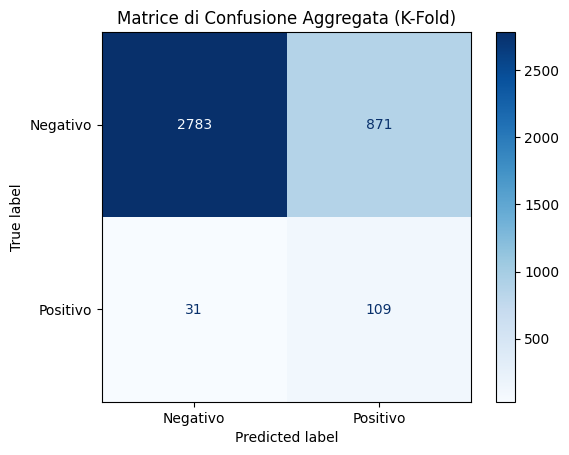

In [70]:
y_pred_classes = (np.array(all_fold_preds) > 0.55).astype(int)
cm = confusion_matrix(all_fold_targets, y_pred_classes)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matrice di Confusione Aggregata (K-Fold)')
plt.savefig('confusion_matrix.png')
plt.show()

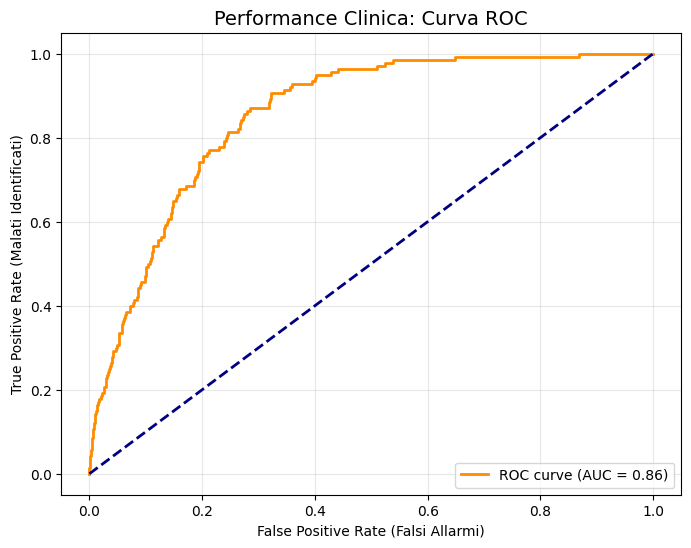

Risultato Finale AUROC: 0.8562


In [55]:
fpr, tpr, _ = roc_curve(all_fold_targets, all_fold_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Performance Clinica: Curva ROC', fontsize=14)
plt.xlabel('False Positive Rate (Falsi Allarmi)')
plt.ylabel('True Positive Rate (Malati Identificati)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Risultato Finale AUROC: {roc_auc:.4f}")

In [58]:
# 1. Recuperiamo gli ID dei pazienti del test set (se non l'hai già fatto)
test_ids = test_patients['subject_id'].values
test_df = df_clean[df_clean['subject_id'].isin(test_ids)].copy()

# 2. Creiamo il Dataset di test usando la TUA classe MimicDataset
test_dataset = MimicDataset(
    test_df, 
    seq_cols=colonne_lstm, 
    static_cols=colonne_mlp
)

# 3. Creiamo il DataLoader di test usando la TUA funzione mimic_collate
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False, 
    collate_fn=mimic_collate # Fondamentale per il padding!
)

print(f"test_loader creato con successo! Contiene {len(test_dataset)} pazienti.")

test_loader creato con successo! Contiene 670 pazienti.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 24.96it/s]


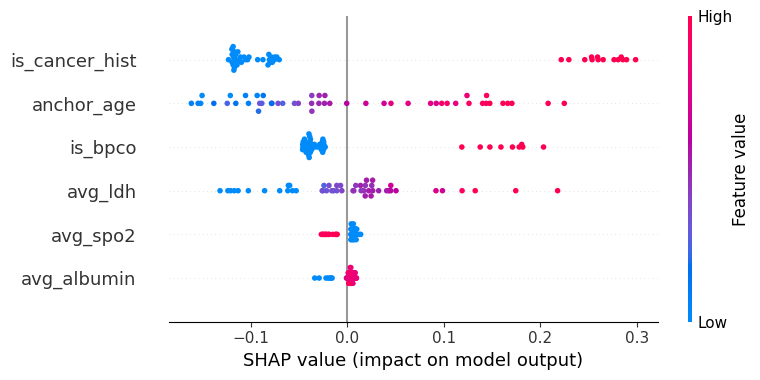

In [62]:
batch = next(iter(test_loader))
test_seqs, test_statics, test_targets, test_lens = batch
test_seqs, test_statics = test_seqs.to(device), test_statics.to(device)


def predict_for_shap(static_input_np):
    model.eval()
    static_tensor = torch.tensor(static_input_np, dtype=torch.float32).to(device)
    
    batch_size_shap = static_tensor.shape[0]
    
    
    current_seq = test_seqs[0:1].expand(batch_size_shap, -1, -1)
    current_lens = test_lens[0:1].expand(batch_size_shap)
    
    with torch.no_grad():
        output = model(current_seq, current_lens, static_tensor)
        return torch.sigmoid(output).cpu().numpy()


explainer = shap.KernelExplainer(predict_for_shap, test_statics[:50].cpu().numpy())

shap_values = explainer.shap_values(test_statics[:50].cpu().numpy())

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_statics[:50].cpu().numpy(), feature_names=colonne_mlp)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 24.97it/s]


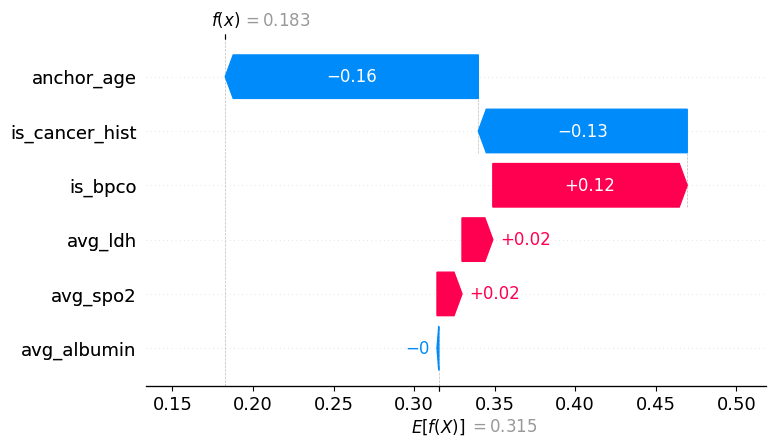

In [ ]:
paziente_da_testare = test_statics[0:1].cpu().numpy() 

explainer = shap.KernelExplainer(predict_for_shap, test_statics[:20].cpu().numpy())

shap_values_singolo = explainer.shap_values(paziente_da_testare)

plt.figure(figsize=(10, 6))
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, 
    shap_values_singolo[0], 
    feature_names=colonne_mlp
)

In [72]:
y_true_final = np.array(all_fold_targets)
y_pred_final = np.array(all_fold_preds)

config = {
    "seq_input_size": DIM_SEQ,
    "static_input_size": DIM_STATIC,
    "hidden_size": 64,
    "final_threshold": 0.55,  # La tua scelta definitiva
    "colonne_lstm": colonne_lstm,
    "colonne_mlp": colonne_mlp,
    "model_type": "LSTM+MLP_Hybrid"
}

with open('model_config_v2.json', 'w') as f:
    json.dump(config, f, indent=4)

# 2. Salviamo i risultati per i grafici del sito
final_results_df = pd.DataFrame({
    'y_true': y_true_final,
    'y_prob': y_pred_final,
    'y_pred_binary': (y_pred_final > 0.55).astype(int)
})
final_results_df.to_csv('final_test_results_055.csv', index=False)

print("Configurazione salvata con soglia 0.55. Sei pronto per il deploy finale!")

Configurazione salvata con soglia 0.55. Sei pronto per il deploy finale!


In [73]:
# 1. Salvataggio del modello (state_dict è il modo più pulito e professionale)
path_modello = "mimic_lstm_model_final_055.pth"

torch.save(model.state_dict(), path_modello)

print(f"Modello salvato correttamente in: {path_modello}")


Modello salvato correttamente in: mimic_lstm_model_final_055.pth


In [74]:
joblib.dump(scaler, 'scaler_sequences.joblib')

['scaler_sequences.joblib']